In [230]:
import pandas as pd 
import prince
import mca
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import statsmodels.api as sm

In [ ]:
#SECTION 1: MCA-based variables

In [4]:
results = pd.read_csv('mca-results.csv', index_col=0, header=0)
results

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
GEDIV__1,-0.332859,0.084166,-0.029490,-0.978427,-0.184807,-1.491007,-0.455783,-0.538289,1.059034,-0.296889,...,0.030197,0.041114,-0.013568,-0.006899,0.037647,0.010507,-0.019759,-0.006870,-0.005699,0.026853
GEDIV__2,-0.042103,-0.066681,0.223854,-1.188843,0.579510,0.041794,-1.392190,-0.830981,0.879401,0.905578,...,-0.000757,-0.009830,-0.027702,0.007028,0.017458,-0.009297,-0.026175,-0.012799,0.005485,-0.000880
GEDIV__3,-0.337754,0.559762,-0.177937,0.182685,0.606899,-0.173228,-0.561609,0.307572,-1.862930,-0.495734,...,0.004688,0.022232,-0.003775,0.026419,0.028014,-0.012147,-0.002600,-0.017202,0.008310,-0.003296
GEDIV__4,-0.366609,0.672512,-0.411714,1.002868,1.324908,-0.484481,0.209334,1.143091,1.030083,1.228274,...,-0.007333,0.021253,-0.012089,0.031221,0.016262,0.010321,-0.014174,-0.020407,-0.002566,0.018036
GEDIV__5,0.322288,0.067060,-0.554300,-0.506451,-0.773744,0.920568,-0.066231,1.196249,0.446795,-0.596501,...,-0.015982,-0.028424,-0.015986,-0.044177,-0.045965,-0.004751,-0.008109,0.017656,0.007616,-0.021184
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PRTAGE_C__3,-0.283363,-0.211976,0.041250,0.199908,-0.127458,0.141178,-0.000424,0.072655,0.027838,-0.002557,...,-0.072612,-0.048668,0.056424,-0.031690,-0.135405,-0.185828,0.145796,0.158839,-0.188014,-0.029739
PRTAGE_C__4,-0.422932,-0.158969,0.127490,0.102498,-0.170185,0.269272,-0.053560,0.009755,0.088144,-0.000775,...,-0.021567,0.231497,0.042551,0.121015,-0.005231,0.173898,-0.162637,0.046826,0.125583,0.024006
PRTAGE_C__5,-0.133652,0.232252,0.080882,-0.273240,0.003844,0.021594,0.076046,-0.113922,-0.015203,-0.003979,...,0.324457,-0.222253,-0.169468,-0.194781,0.222124,-0.005767,0.036715,-0.319389,0.127666,-0.149577
PRTAGE_C__6,0.054321,0.597152,0.088434,-0.410313,0.121391,-0.115109,0.129329,-0.151733,0.016959,0.118531,...,-0.387591,0.227315,0.195021,0.103879,-0.257275,-0.003943,-0.095921,0.300327,-0.190121,0.192995


In [78]:
#keep only coordinates >1 or <-1
sig_res = results[results > 1]
sig_res = sig_res.dropna(how='all', axis=1)
sig_res = sig_res.dropna(how='all', axis=0)
a_s_r = sig_res.transpose()
s_res = sig_res
sig_res

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
GEDIV__1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.059034,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GEDIV__2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GEDIV__4,NaN,NaN,NaN,1.002868,1.324908,NaN,NaN,1.143091,1.030083,1.228274,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GEDIV__5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.196249,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GEDIV__6,NaN,NaN,NaN,NaN,NaN,1.434142,1.103872,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HRNUMHOU_c__6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.181517,NaN
PRNMCHLD_C__4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PRNMCHLD_C__5,NaN,NaN,NaN,1.215297,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PRTAGE_C__1,1.041965,NaN,NaN,1.752299,1.876394,NaN,NaN,1.302051,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [99]:
#list variables that contribute to >50% of the variance in CORR
list(a_s_r.columns)

['GEDIV__1',
 'GEDIV__2',
 'GEDIV__4',
 'GEDIV__5',
 'GEDIV__6',
 'GEDIV__7',
 'GEDIV__8',
 'GESTFIPS__1',
 'GESTFIPS__2',
 'GESTFIPS__4',
 'GESTFIPS__5',
 'GESTFIPS__8',
 'GESTFIPS__9',
 'GESTFIPS__10',
 'GESTFIPS__11',
 'GESTFIPS__12',
 'GESTFIPS__13',
 'GESTFIPS__15',
 'GESTFIPS__16',
 'GESTFIPS__17',
 'GESTFIPS__19',
 'GESTFIPS__20',
 'GESTFIPS__21',
 'GESTFIPS__22',
 'GESTFIPS__23',
 'GESTFIPS__24',
 'GESTFIPS__25',
 'GESTFIPS__26',
 'GESTFIPS__27',
 'GESTFIPS__28',
 'GESTFIPS__29',
 'GESTFIPS__30',
 'GESTFIPS__31',
 'GESTFIPS__32',
 'GESTFIPS__33',
 'GESTFIPS__34',
 'GESTFIPS__35',
 'GESTFIPS__36',
 'GESTFIPS__37',
 'GESTFIPS__38',
 'GESTFIPS__40',
 'GESTFIPS__41',
 'GESTFIPS__42',
 'GESTFIPS__44',
 'GESTFIPS__45',
 'GESTFIPS__46',
 'GESTFIPS__47',
 'GESTFIPS__48',
 'GESTFIPS__49',
 'GESTFIPS__50',
 'GESTFIPS__51',
 'GESTFIPS__53',
 'GESTFIPS__54',
 'GESTFIPS__55',
 'GESTFIPS__56',
 'GTMETSTA__3',
 'HEHOUSUT__2',
 'HEHOUSUT__3',
 'HEHOUSUT__4',
 'HEHOUSUT__5',
 'HEHOUSUT__6',
 'H

In [87]:
var = []
subcat = []

In [102]:
#determine which variables are positively correlated to CORR variable
for x in list(a_s_r.columns):
    y = str(x)
    z = y.split('__')[0]
    a = y.split('__')[1]
    var.append(z)
    subcat.append(a)

In [105]:
s_res['var'] = var
s_res['subcat'] = subcat
s_res

ValueError: Length of values (258) does not match length of index (129)

In [96]:
s_res.loc[s_res['var'] == 'PRNMCHLD_C', 'var'] = 'PRNMCHLD_c'
s_res.loc[s_res['var'] == 'PRTAGE_C', 'var'] = 'PRTAGE_c'
s_res

,0,1,2,3,4,5,6,7,8,9,...,42,43,44,45,46,47,48,49,var,subcat
GEDIV__1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.059034,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GEDIV,1
GEDIV__2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GEDIV,2
GEDIV__4,NaN,NaN,NaN,1.002868,1.324908,NaN,NaN,1.143091,1.030083,1.228274,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GEDIV,4
GEDIV__5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.196249,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GEDIV,5
GEDIV__6,NaN,NaN,NaN,NaN,NaN,1.434142,1.103872,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GEDIV,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HRNUMHOU_c__6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.181517,NaN,HRNUMHOU_c,6
PRNMCHLD_C__4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PRNMCHLD_c,4
PRNMCHLD_C__5,NaN,NaN,NaN,1.215297,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PRNMCHLD_c,5
PRTAGE_C__1,1.041965,NaN,NaN,1.752299,1.876394,NaN,NaN,1.302051,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PRTAGE_c,1


In [233]:
#SECTION 2: CORRELATION RATES ALL PEOPLE
data = pd.read_csv('people.csv')
allcat = pd.read_csv('allcat.csv')

In [236]:
cols_to_use = ['GESTFIPS', 'GTMETSTA', 'HEHOUSUT', 'HETENURE',
       'HRHTYPE', 'HRNUMHOU_c', 'HUSPNISH', 'PEABSRSN', 'PEAFEVER', 
        'PECERT1', 'PECERT3',
       'PECYC', 'PEDIPGED', 'PEDISDRS', 'PEDISEAR', 'PEDISEYE', 'PEDISOUT',
       'PEDISPHY', 'PEDISREM',  'PEERNCOV', 'PEERNHRY', 
       'PEGRPROF', 'PEHSPNON', 'PEMARITL', 'PEMJOT',
       'PESEX', 'PRCITSHP', 'PRDISFLG', 
       'PRERNHLY_c', 'PRMARSTA', 'PRNMCHLD_c', 'PRTAGE_c', 'PTDTRACE',
       'PUAFEVER', 'PUBUS1','TUCASEID','TULINENO']
data = data.merge(allcat[cols_to_use],how='left', on=['TUCASEID','TULINENO'])

In [239]:
data = data.drop(['Unnamed: 0','TUCASEID','TULINENO','TELE2019','TELECOVID','TELENOW','EMPA','EMPB','EMPC','EMPD'], axis=1)

In [242]:
#one hot encode and get summary stats for each category and response, by correlation status
data_ohc = pd.get_dummies(data, columns=['CORR','GESTFIPS', 'GTMETSTA', 'HEHOUSUT', 'HETENURE',
       'HRHTYPE', 'HRNUMHOU_c', 'HUSPNISH', 'PEABSRSN', 'PEAFEVER', 
        'PECERT1',  'PECERT3',
       'PECYC', 'PEDIPGED', 'PEDISDRS', 'PEDISEAR', 'PEDISEYE', 'PEDISOUT',
       'PEDISPHY', 'PEDISREM', 'PEERNCOV', 'PEERNHRY', 
       'PEGRPROF', 'PEHSPNON', 'PEMARITL',  'PEMJOT',
       'PESEX', 'PRCITSHP', 'PRDISFLG',
       'PRERNHLY_c', 'PRMARSTA', 'PRNMCHLD_c', 'PRTAGE_c', 'PTDTRACE',
       'PUAFEVER', 'PUBUS1','HRYEAR4','EMPSTAT','TELEALL','PEAFNOW','PEMLR','PEHRWANT','PESCHENR','PEDWWNTO'])

In [245]:
data_ohc

,CORR_1,CORR_2,GESTFIPS_1,GESTFIPS_2,GESTFIPS_4,GESTFIPS_5,GESTFIPS_6,GESTFIPS_8,GESTFIPS_9,GESTFIPS_10,...,PEHRWANT_1,PEHRWANT_2,PEHRWANT_3,PESCHENR_-1,PESCHENR_2,PEDWWNTO_-1,PEDWWNTO_1,PEDWWNTO_2,PEDWWNTO_4,PEDWWNTO_5
0,True,False,False,False,False,False,True,False,False,False,...,False,False,False,True,False,True,False,False,False,False
1,True,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,True,False,False,False,False
2,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,True,False,False,False,False
3,True,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,True,False,False,False,False
4,True,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
231415,False,True,False,False,False,False,False,False,False,False,...,False,False,False,True,False,True,False,False,False,False
231416,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,True,False,False,False,False
231417,False,True,False,False,False,False,False,False,False,False,...,False,False,False,True,False,True,False,False,False,False
231418,False,True,False,False,False,False,True,False,False,False,...,False,False,False,False,True,True,False,False,False,False


In [248]:
ohc_sum = pd.DataFrame(data_ohc.groupby(['CORR_1']).sum())

In [251]:
ohc_sum.to_csv('correlation_summary.csv',header=True)

In [351]:
sum = ohc_sum.transpose()
sum.reset_index()
sum.info()

KeyError: 'False'

In [360]:
#calculate percentage with correlated telework/employment status by category
sum['percentage'] = pd.to_numeric(sum[1]/(sum[1] + sum[0]))
sum

CORR_1,False,True,percentage
CORR_2,113290,0,0.000000
GESTFIPS_1,2191,2341,0.516549
GESTFIPS_2,299,351,0.540000
GESTFIPS_4,2483,2550,0.506656
GESTFIPS_5,1166,1330,0.532853
...,...,...,...
PEDWWNTO_-1,90634,117942,0.565463
PEDWWNTO_1,3107,4,0.001286
PEDWWNTO_2,19420,77,0.003949
PEDWWNTO_4,10,66,0.868421


In [363]:
#drop rows that represent n/a answers (neg value in variable response)
sum_s = sum[sum.index.str.contains('_-')==False]
#drop rows with <0.1% (<231) valid responses
sum_s = sum_s[(sum_s[0]+sum_s[1]) > 231]
sum_s.info()

<class 'pandas.core.frame.DataFrame'>
Index: 181 entries, CORR_2 to PEDWWNTO_2
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   False       181 non-null    int64  
 1   True        181 non-null    int64  
 2   percentage  181 non-null    float64
dtypes: float64(1), int64(2)
memory usage: 5.7+ KB


/opt/conda/envs/anaconda-2024.02-py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


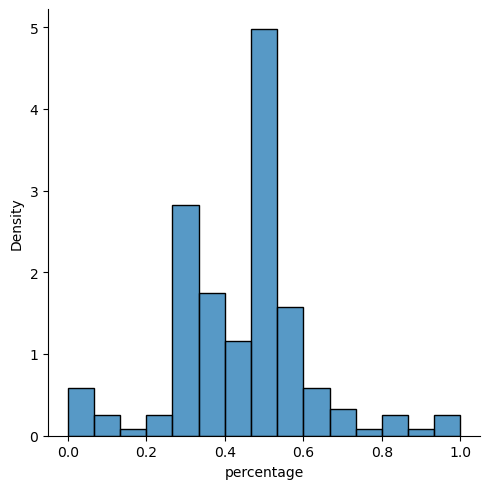

In [378]:
#plot distribution of True values
sns.displot(sum_s, x='percentage', stat='density')

<Axes: xlabel='percentage'>

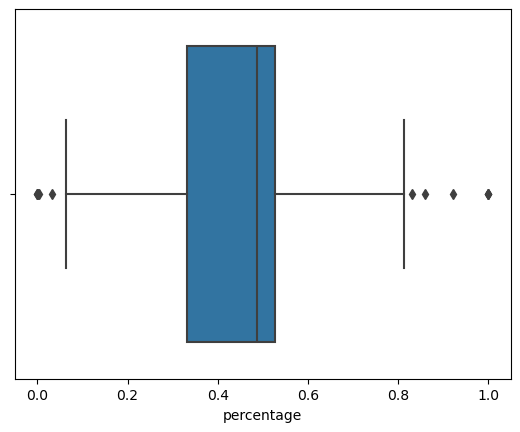

In [381]:
#boxplot of distribution
sns.boxplot(sum_s, x='percentage')

array([[<Axes: title={'center': 'percentage'}>]], dtype=object)

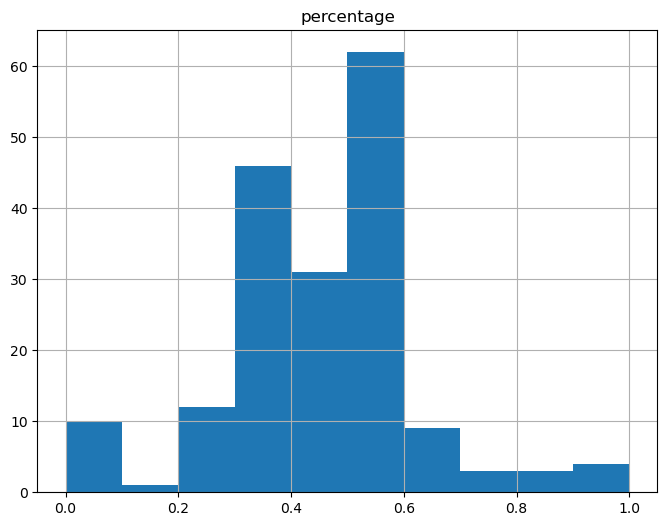

In [395]:
sum_s['percentage'].describe()
sum_s.hist(column=['percentage'],bins=10, figsize=(8,6))

In [399]:
sum_s['percentage'].describe()

count    181.000000
mean       0.445664
std        0.171484
min        0.000000
25%        0.332726
50%        0.486413
75%        0.527152
max        1.000000
Name: percentage, dtype: float64

In [366]:
sum_s.to_csv('correlation_summary.csv',header=True)